#**Road Accident Injury Severity Prediction using End-to-End Machine Learning Pipelines**

## **1. Introduction**

Road traffic accidents are a major public safety concern worldwide, with outcomes ranging from minor injuries to fatal incidents. Understanding the factors that contribute to injury severity can support better risk assessment, policy decisions, and preventive measures.

This project aims to predict injury severity using the **FARS (Fatality Analysis Reporting System) dataset**, which contains **over 100,000 accident records from the United States**. The task is formulated as a multi-class classification problem, where the goal is to predict the severity of injuries based on accident-related features such as age, seating position, restraint use, and alcohol involvement.

To address this, multiple machine learning pipelines are developed using appropriate preprocessing techniques for mixed data types. The models are evaluated using metrics that account for class imbalance, including macro-F1, in addition to accuracy. The project focuses not only on predictive performance but also on understanding model behaviour and limitations.

## **2. Dataset Overview**

The FARS dataset consists of detailed records of road traffic accidents in the United States, including information about vehicle occupants, crash conditions, and injury outcomes. The dataset used in this project contains over 100,000 observations and a mix of numerical and categorical features.

Key input features include:

* Demographic attributes (e.g., age)
* Vehicle-related factors (e.g., seating position, restraint use)
* Behavioural indicators (e.g., alcohol involvement)

The target variable, `INJURY_SEVERITY`, represents the level of harm sustained by an individual. This defines a multi-class classification problem, where the objective is to predict injury severity based on accident-related features.

## **3. Exploratory Data Analysis (EDA)**

This section explores the structure and key characteristics of the dataset to inform preprocessing and modelling decisions. The focus is on understanding feature types, identifying class imbalance in the target variable, and examining relationships between selected features and injury severity.

The insights from this analysis guide the design of machine learning pipelines and evaluation strategy.

#### **3.1 Basic Structure**

In [1]:
from google.colab import drive
from pathlib import Path

# Force remount ensures fresh connection
drive.mount('/content/drive', force_remount=True)

import pandas as pd              # Data manipulation
import numpy as np               # Numerical operations
import matplotlib.pyplot as plt  # Visualisation

# Define the path to the dataset stored in Google Drive
fars_path = Path("/content/drive/MyDrive/fars (1).csv")

# Read the CSV file into a pandas DataFrame
fars = pd.read_csv(fars_path)

# Display the first few rows to understand structure and columns
fars.head()

Mounted at /content/drive


,CASE_STATE,AGE,SEX,PERSON_TYPE,SEATING_POSITION,RESTRAINT_SYSTEM-USE,AIR_BAG_AVAILABILITY/DEPLOYMENT,EJECTION,EJECTION_PATH,EXTRICATION,...,DRUG_TEST_RESULTS_(2_of_3),DRUG_TEST_TYPE_(3_of_3),DRUG_TEST_RESULTS_(3_of_3),HISPANIC_ORIGIN,TAKEN_TO_HOSPITAL,RELATED_FACTOR_(1)-PERSON_LEVEL,RELATED_FACTOR_(2)-PERSON_LEVEL,RELATED_FACTOR_(3)-PERSON_LEVEL,RACE,INJURY_SEVERITY
0,Alabama,34,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Air_Bag_Available_but_Not_Deployed_for_this_Seat,Totally_Ejected,Unknown,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
1,Alabama,20,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Deployed_Air_Bag_from_Front,Totally_Ejected,Unknown,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
2,Alabama,43,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury
3,Alabama,38,Female,Passenger_of_a_Motor_Vehicle_in_Transport,Front_Seat_-_Right_Side,Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0,Not_Tested_for_Drugs,0,Not_a_Fatality_(Not_Applicable),Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_a_Fatality_(Not_Applicable),Incapaciting_Injury
4,Alabama,50,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Deployed_Air_Bag_from_Front,Not_Ejected,Not_Ejected/Not_Applicable,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury


In [2]:
fars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100968 entries, 0 to 100967
Data columns (total 30 columns):
 #   Column                               Non-Null Count   Dtype 
---  ------                               --------------   ----- 
 0   CASE_STATE                           100968 non-null  object
 1   AGE                                  100968 non-null  int64 
 2   SEX                                  100968 non-null  object
 3   PERSON_TYPE                          100968 non-null  object
 4   SEATING_POSITION                     100968 non-null  object
 5   RESTRAINT_SYSTEM-USE                 100968 non-null  object
 6   AIR_BAG_AVAILABILITY/DEPLOYMENT      100968 non-null  object
 7   EJECTION                             100968 non-null  object
 8   EJECTION_PATH                        100968 non-null  object
 9   EXTRICATION                          100968 non-null  object
 10  NON_MOTORIST_LOCATION                100968 non-null  object
 11  POLICE_REPORTED_ALCOHOL_IN

The dataset contains over 100,000 observations and a mix of categorical and numerical features. Most variables are categorical, describing crash conditions and occupant characteristics, while AGE is the only continuous feature. This indicates that preprocessing will primarily involve encoding categorical variables.

#### **3.2 Feature Types**

In [3]:
num_cols = fars.select_dtypes(include=['int64', 'float64']).columns
cat_cols = fars.select_dtypes(include=['object']).columns

print("Number of numerical features:", len(num_cols))
print("Number of categorical features:", len(cat_cols))

Number of numerical features: 5
Number of categorical features: 25


####**3.3 Missing Values**

In [4]:
fars.isnull().sum().sort_values(ascending=False).head(10)

,0
CASE_STATE,0
AGE,0
SEX,0
PERSON_TYPE,0
SEATING_POSITION,0
RESTRAINT_SYSTEM-USE,0
AIR_BAG_AVAILABILITY/DEPLOYMENT,0
EJECTION,0
EJECTION_PATH,0
EXTRICATION,0


The dataset does not contain explicit missing values (NaNs). However, several categorical features include values such as "Unknown" or "Not Reported", which effectively act as missing categories. These values are retained and handled during preprocessing using encoding techniques.

####**3.4 Target Distribution (Class Imbalance)**

In [5]:
injury_counts = fars["INJURY_SEVERITY"].value_counts()
injury_props = fars["INJURY_SEVERITY"].value_counts(normalize=True)

print(injury_counts)
print(injury_props)

INJURY_SEVERITY
Fatal_Injury                      42116
No_Injury                         20007
Incapaciting_Injury               15072
Nonincapaciting_Evident_Injury    13890
Possible_Injury                    8674
Unknown                             901
Injured_Severity_Unknown            299
Died_Prior_to_Accident                9
Name: count, dtype: int64
INJURY_SEVERITY
Fatal_Injury                      0.417122
No_Injury                         0.198152
Incapaciting_Injury               0.149275
Nonincapaciting_Evident_Injury    0.137568
Possible_Injury                   0.085908
Unknown                           0.008924
Injured_Severity_Unknown          0.002961
Died_Prior_to_Accident            0.000089
Name: proportion, dtype: float64


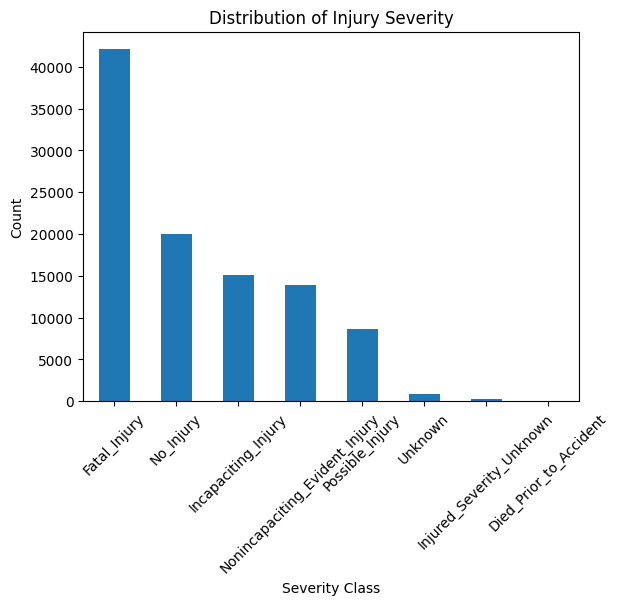

In [6]:
import matplotlib.pyplot as plt

injury_counts.plot(kind="bar")
plt.title("Distribution of Injury Severity")
plt.xlabel("Severity Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The target variable shows strong class imbalance, with **Fatal Injury accounting for the largest proportion (~ 42%), followed by No Injury (~ 20%)**. Several classes, such as Died Prior to Accident, are extremely rare.

This imbalance makes accuracy an unreliable metric, as models may achieve high accuracy by favouring majority classes. Therefore, evaluation will focus on macro-F1 score, which gives equal importance to all classes. Stratified sampling and class-weighted models will also be used to improve minority class performance.

####**3.5 AGE**

In [7]:
fars["AGE"].describe()

,AGE
count,100968.000000
mean,37.106707
std,22.109641
min,0.000000
25%,20.000000
50%,32.000000
75%,49.000000
max,99.000000


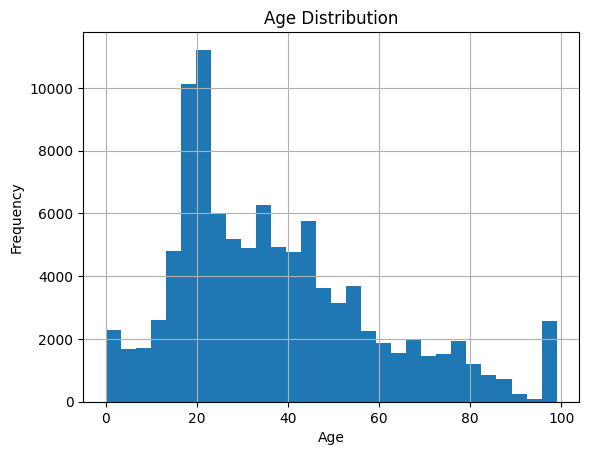

In [8]:
fars["AGE"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

The AGE feature is right-skewed, with most individuals **between 18 and 40 years old**. Since AGE is the only numerical variable, it will be standardised during preprocessing to ensure compatibility with models sensitive to feature scale.


####**3.6 Key Relationships**

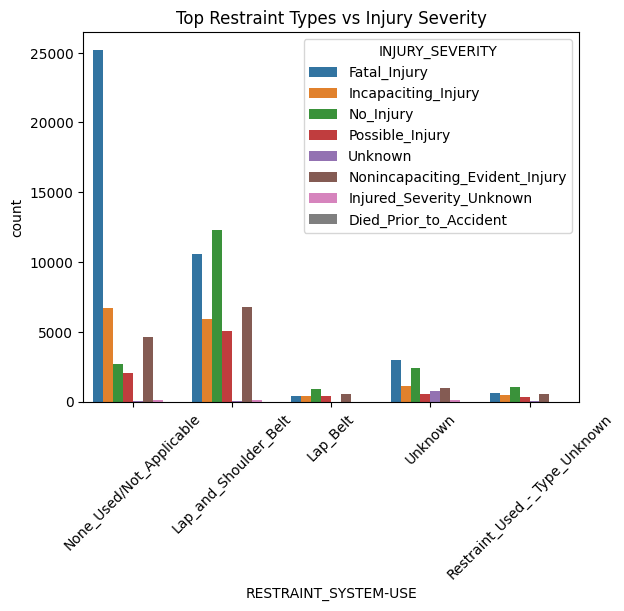

In [9]:
import seaborn as sns
top_categories = fars["RESTRAINT_SYSTEM-USE"].value_counts().nlargest(5).index
filtered_df = fars[fars["RESTRAINT_SYSTEM-USE"].isin(top_categories)]
sns.countplot(data=filtered_df, x="RESTRAINT_SYSTEM-USE", hue="INJURY_SEVERITY")
plt.xticks(rotation=45)
plt.title("Top Restraint Types vs Injury Severity")
plt.show()

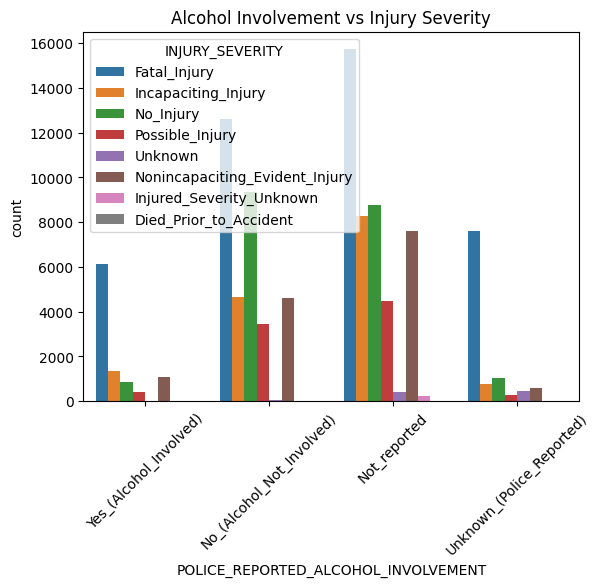

In [10]:
top_categories = fars["POLICE_REPORTED_ALCOHOL_INVOLVEMENT"].value_counts().nlargest(5).index
filtered_df = fars[fars["POLICE_REPORTED_ALCOHOL_INVOLVEMENT"].isin(top_categories)]
sns.countplot(data=fars, x="POLICE_REPORTED_ALCOHOL_INVOLVEMENT", hue="INJURY_SEVERITY")
plt.xticks(rotation=45)
plt.title("Alcohol Involvement vs Injury Severity")
plt.show()

The categorical features show clear variation across injury severity levels. In particular, restraint system use and alcohol involvement demonstrate noticeable differences in outcome distribution.

These patterns suggest that categorical variables contain meaningful predictive information and justify the use of encoding techniques. Tree-based models are expected to capture interactions between these variables effectively.

#### **3.7 EDA Summary**
* The dataset is predominantly categorical, with AGE as the only numerical feature
* The target variable is highly imbalanced, requiring careful evaluation beyond accuracy
* Key categorical variables show meaningful relationships with injury severity
* No explicit missing values are present, though some categories represent unknown information

These observations guide the preprocessing strategy, including encoding of categorical variables, scaling of AGE, and the use of class-aware evaluation metrics.

##**4. Data Preprocessing**

To prepare the dataset for machine learning, preprocessing is applied to handle mixed data types and ensure consistent transformations across models. The dataset consists primarily of categorical features along with a single numerical feature (AGE).

Preprocessing includes:

* separating features and target
* identifying numerical and categorical variables
* scaling numerical data
* encoding categorical variables
* integrating all transformations within a unified pipeline

Using pipelines ensures that preprocessing is applied consistently during training, validation, and testing, preventing data leakage and improving model reliability.

In [11]:
# Separate features and target
X = fars.drop(columns=["INJURY_SEVERITY"])
y = fars["INJURY_SEVERITY"]

####**4.1 Numerical vs Categorical Features**
Most variables in this dataset are categorical. The main numerical variable is AGE, which will be scaled to zero-mean and unit-variance. All other fields are treated as categorical and will be one-hot encoded to allow linear and tree-based models to use them effectively.

In [12]:
numeric_features = ["AGE"]
categorical_features = [col for col in X.columns if col not in numeric_features]

numeric_features, categorical_features[:5]

(['AGE'],
 ['CASE_STATE',
  'SEX',
  'PERSON_TYPE',
  'SEATING_POSITION',
  'RESTRAINT_SYSTEM-USE'])

#### **4.2 Numerical Processing**

The numerical feature AGE is standardised using StandardScaler to ensure it is on a comparable scale with encoded categorical features. Scaling is particularly important for models such as Logistic Regression and SVM, which are sensitive to feature magnitude.

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#### **4.3 Categorical Processing**

Categorical variables are encoded using one-hot encoding to convert them into a numerical format suitable for machine learning models. Categories such as "Unknown" and "Not Reported" are retained as valid levels.

An imputer is included to ensure robustness in case missing values appear during training or evaluation. The encoder is configured to handle unseen categories during testing without errors.

In [14]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

#### **4.4 Combining Transformations**

The numerical and categorical preprocessing steps are combined using a **ColumnTransformer**. This allows both types of features to be processed simultaneously within a single pipeline.

Embedding preprocessing within the model pipeline ensures that transformations are applied consistently across cross-validation and testing, preventing data leakage and maintaining reproducibility.

In [15]:
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## **5. Train–Test Split and Cross-Validation Strategy**

To evaluate model performance reliably, the dataset is divided into training and testing subsets using an **80/20 split**. Since the target variable is imbalanced, a stratified split is applied to preserve class proportions in both sets. This ensures that minority classes are represented during both training and evaluation.

**Model selection** and **hyperparameter tuning** are performed using cross-validation on the training data only. Specifically, **Stratified K-Fold cross-validation** is used to maintain class distribution within each fold.

This approach provides:

* a more robust estimate of model performance compared to a single split
* reduced risk of overfitting
* fair comparison across different models

The test set is kept completely unseen during training and tuning and is used only for final evaluation.


In [16]:
# Split the dataset into training and test sets
from sklearn.model_selection import train_test_split

# Perform an 80/20 train-test split
# - stratify=y ensures class proportions of INJURY_SEVERITY
#   are preserved in both training and test sets
# - random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shape of the resulting splits
X_train.shape, X_test.shape

((80774, 29), (20194, 29))

#### **5.1 Stratified Train/Test Split**

The dataset is split into **80% training and 20% testing** data. Stratification ensures that the distribution of injury severity classes remains consistent across both subsets.

This is particularly important due to class imbalance, as it prevents rare classes from being underrepresented or missing entirely in either split. Maintaining class proportions allows for more reliable evaluation using metrics such as macro-F1.


#### **5.2 Cross-Validation Strategy**

A **Stratified K-Fold cross-validation approach** is used during **model training and hyperparameter tuning**. The training data is divided into five folds, where each fold preserves the class distribution of the target variable.

Each model is trained and validated across multiple folds, and the average macro-F1 score is used to select the best hyperparameters.

This ensures:

* stable performance estimates across different data splits
* better generalisation compared to a single validation set
* fair optimisation under class imbalance conditions

In [17]:
from sklearn.model_selection import StratifiedKFold

# Use Stratified K-Fold cross-validation to preserve
# class proportions of INJURY_SEVERITY in each fold
cv = StratifiedKFold(
    n_splits=5,        # Number of cross-validation folds
    shuffle=True,      # Shuffle data before splitting into folds
    random_state=42    # Ensure reproducibility
)

The cross-validation object is passed into GridSearchCV for systematic hyperparameter tuning.

## **6. Machine Learning Pipelines and Hyperparameter Tuning**

Four supervised learning pipelines were constructed to classify **INJURY_SEVERITY**. Each pipeline embeds the preprocessing stage (imputation, scaling and one-hot encoding) inside a scikit-learn `Pipeline`, ensuring that transformations occur within each fold during cross-validation and preventing data leakage.

For each model, a small but meaningful hyperparameter grid is explored using `GridSearchCV`, with **Stratified K-Fold** cross-validation and **macro-F1** as the scoring metric. Macro-F1 is used instead of accuracy because the dataset is imbalanced, and minority classes must be weighted fairly.

A reduced hyperparameter grid was chosen to balance model flexibility with computational feasibility, while still allowing meaningful differences in performance to emerge.

In [18]:
from sklearn.dummy import DummyClassifier

dummy = Pipeline([
    ("preprocess", preprocess),
    ("clf", DummyClassifier(strategy="most_frequent"))
])

dummy.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AGE']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CASE_STATE', 'SEX',
                                                   'PERSON_TYPE',
                                                   'SEATING_POSITION',
                                                   '...
                                                   'DRUG_TEST_TYPE_(1_of_3)',
                                                   'DRUG_TEST_RESULTS_(1_of_3)',
                                                   'DRUG_TEST_TYPE_(2_of_3)',
                                                   'DRUG_TEST_RESULTS_(2_of_3)',
                                                   'DRUG_TEST_TYPE_(3_of_3)',
                                                   'DRUG_TEST_RESULTS_(3_of_3)',
                                                   'HISPANIC_ORIGIN',
                                                   'TAKEN_TO_HOSPITAL',
                                                   'RELATED_FACTOR_(1)-PERSON_LEVEL',
                                                   'RELATED_FACTOR_(2)-PERSON_LEVEL',
                                                   'RELATED_FACTOR_(3)-PERSON_LEVEL',
                                                   'RACE'])])),
                ('clf', DummyClassifier(strategy='most_frequent'))])

#### **6.1 Logistic Regression**

Logistic Regression provides a linear baseline model. Because the classes are imbalanced, the classifier is configured with `class_weight="balanced"`. The inverse regularisation strength **C** is tuned across \[0.1, 1.0, 10.0\] to allow varying degrees of model flexibility.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipe_logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

param_grid_logreg = {
    "clf__C": [0.1, 1.0, 10.0]
}

grid_logreg = GridSearchCV(
    pipe_logreg,
    param_grid_logreg,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)
param_grid_logreg = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
    "clf__penalty": ["l2"]
}
param_grid_logreg
grid_logreg.fit(X_train, y_train)
best_logreg = grid_logreg.best_estimator_
best_logreg

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AGE']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CASE_STATE', 'SEX',
                                                   'PERSON_TYPE',
                                                   'SEATING_POSITION',
                                                   '...
                                                   'DRUG_TEST_RESULTS_(1_of_3)',
                                                   'DRUG_TEST_TYPE_(2_of_3)',
                                                   'DRUG_TEST_RESULTS_(2_of_3)',
                                                   'DRUG_TEST_TYPE_(3_of_3)',
                                                   'DRUG_TEST_RESULTS_(3_of_3)',
                                                   'HISPANIC_ORIGIN',
                                                   'TAKEN_TO_HOSPITAL',
                                                   'RELATED_FACTOR_(1)-PERSON_LEVEL',
                                                   'RELATED_FACTOR_(2)-PERSON_LEVEL',
                                                   'RELATED_FACTOR_(3)-PERSON_LEVEL',
                                                   'RACE'])])),
                ('clf',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000))])

#### **6.2 Random Forest Classifier**

Random Forest is a non-linear ensemble model capable of capturing interactions between categorical variables. Because the dataset is imbalanced, `class_weight="balanced"` is used. A lightweight parameter search is used to control model complexity by exploring the number of trees and maximum depth.

In [20]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))
])

param_grid_rf = {
    "clf__n_estimators": [100],
    "clf__max_depth": [None, 15]
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=3,  # faster for Colab
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
param_grid_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5]
}
param_grid_rf
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
best_rf

Fitting 3 folds for each of 2 candidates, totalling 6 fits


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AGE']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CASE_STATE', 'SEX',
                                                   'PERSON_TYPE',
                                                   'SEATING_POSITION',
                                                   '...
                                                   'DRUG_TEST_RESULTS_(1_of_3)',
                                                   'DRUG_TEST_TYPE_(2_of_3)',
                                                   'DRUG_TEST_RESULTS_(2_of_3)',
                                                   'DRUG_TEST_TYPE_(3_of_3)',
                                                   'DRUG_TEST_RESULTS_(3_of_3)',
                                                   'HISPANIC_ORIGIN',
                                                   'TAKEN_TO_HOSPITAL',
                                                   'RELATED_FACTOR_(1)-PERSON_LEVEL',
                                                   'RELATED_FACTOR_(2)-PERSON_LEVEL',
                                                   'RELATED_FACTOR_(3)-PERSON_LEVEL',
                                                   'RACE'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

#### **6.3 Gradient Boosting Classifier**

Gradient Boosting trains weak learners sequentially to reduce errors. It generally performs well on structured tabular data. Two key hyperparameters are tuned: the learning rate and number of estimators. A reduced parameter grid allows efficient search while maintaining performance.

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

pipe_gb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    "clf__n_estimators": [100],
    "clf__learning_rate": [0.05, 0.1]
}

grid_gb = GridSearchCV(
    pipe_gb,
    param_grid_gb,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
param_grid_gb = {
    "clf__n_estimators": [100, 200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [3, 5]
}
param_grid_gb
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_
best_gb

Fitting 3 folds for each of 2 candidates, totalling 6 fits


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AGE']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CASE_STATE', 'SEX',
                                                   'PERSON_TYPE',
                                                   'SEATING_POSITION',
                                                   '...
                                                   'DRUG_TEST_RESULTS_(1_of_3)',
                                                   'DRUG_TEST_TYPE_(2_of_3)',
                                                   'DRUG_TEST_RESULTS_(2_of_3)',
                                                   'DRUG_TEST_TYPE_(3_of_3)',
                                                   'DRUG_TEST_RESULTS_(3_of_3)',
                                                   'HISPANIC_ORIGIN',
                                                   'TAKEN_TO_HOSPITAL',
                                                   'RELATED_FACTOR_(1)-PERSON_LEVEL',
                                                   'RELATED_FACTOR_(2)-PERSON_LEVEL',
                                                   'RELATED_FACTOR_(3)-PERSON_LEVEL',
                                                   'RACE'])])),
                ('clf',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            random_state=42))])

#### **6.4 Support Vector Classifier (Linear Kernel)**

Support Vector Machines can perform well after one-hot encoding, but are computationally expensive on large datasets. To ensure tractability in Colab, a **linear kernel** with a single value for \(C\) is used. The model uses `class_weight="balanced"` to offset class imbalance.

In [22]:
from sklearn.svm import SVC

pipe_svc = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", SVC(kernel="linear", class_weight="balanced"))
])

param_grid_svc = {
    "clf__C": [1]
}

grid_svc = GridSearchCV(
    pipe_svc,
    param_grid_svc,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
param_grid_svc = {
    "clf__C": [0.1, 1, 10]
}
param_grid_svc
grid_svc.fit(X_train, y_train)
best_svc = grid_svc.best_estimator_
best_svc

Fitting 3 folds for each of 1 candidates, totalling 3 fits


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['AGE']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CASE_STATE', 'SEX',
                                                   'PERSON_TYPE',
                                                   'SEATING_POSITION',
                                                   '...
                                                   'DRUG_TEST_TYPE_(1_of_3)',
                                                   'DRUG_TEST_RESULTS_(1_of_3)',
                                                   'DRUG_TEST_TYPE_(2_of_3)',
                                                   'DRUG_TEST_RESULTS_(2_of_3)',
                                                   'DRUG_TEST_TYPE_(3_of_3)',
                                                   'DRUG_TEST_RESULTS_(3_of_3)',
                                                   'HISPANIC_ORIGIN',
                                                   'TAKEN_TO_HOSPITAL',
                                                   'RELATED_FACTOR_(1)-PERSON_LEVEL',
                                                   'RELATED_FACTOR_(2)-PERSON_LEVEL',
                                                   'RELATED_FACTOR_(3)-PERSON_LEVEL',
                                                   'RACE'])])),
                ('clf', SVC(C=1, class_weight='balanced', kernel='linear'))])

Each of the four tuned models now contains both the preprocessing stage and the optimal hyperparameters identified via cross-validation. These models can now be evaluated on the **held-out 20% test set** to provide an unbiased measure of generalisation performance.

In the next section, we assess all four models using macro-F1, precision, recall, and confusion matrices to compare predictive performance — with particular emphasis on minority injury-severity categories, where balanced evaluation is most critical.

## **7. Evaluation and Performance Metrics**

Model performance is evaluated on the held-out **20% test set**, which was not used during training or cross-validation. Because the target variable is imbalanced, two metrics are reported:

- **Accuracy** — overall proportion of correct predictions.
- **Macro-averaged F1 score** — averages F1 per class, giving equal weight to minority classes.

Macro-F1 is therefore the more reliable indicator of performance in this task.

In [23]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(name, model, X_test, y_test):
    # Generate predictions on the test set
    y_pred = model.predict(X_test)

    # Compute overall accuracy
    acc = accuracy_score(y_test, y_pred)

    # Compute macro-averaged F1 score (treats all classes equally)
    f1m = f1_score(y_test, y_pred, average="macro")

    return {
        "model": name,
        "accuracy": acc,
        "f1_macro": f1m
    }

In [24]:
# Initialise an empty list to store evaluation results
results = []

# Evaluate each tuned model on the test set
results.append(evaluate_model(
    "Dummy (Baseline)",
    dummy,
    X_test,
    y_test
))

results.append(evaluate_model(
    "Logistic Regression",
    best_logreg,
    X_test,
    y_test
))

results.append(evaluate_model(
    "Random Forest",
    best_rf,
    X_test,
    y_test
))

results.append(evaluate_model(
    "Gradient Boosting",
    best_gb,
    X_test,
    y_test
))

results.append(evaluate_model(
    "SVC (Linear)",
    best_svc,
    X_test,
    y_test
))

In [25]:
import pandas as pd

# Create a DataFrame from the list of evaluation dictionaries
results_df = pd.DataFrame(results)

# Display the summary table of model performance
results_df.sort_values(by="f1_macro", ascending=False)

,model,accuracy,f1_macro
2,Random Forest,0.775825,0.548648
3,Gradient Boosting,0.797415,0.547820
1,Logistic Regression,0.781074,0.505941
4,SVC (Linear),0.778994,0.502486
0,Dummy (Baseline),0.417104,0.073584


#### **7.1 Overall Model Comparison**

Gradient Boosting achieved the **highest accuracy** on the test set (0.7974), meaning it produced the most correct predictions overall. However, Random Forest achieved the **highest macro-F1 score** (0.5486), slightly higher than Gradient Boosting (0.5478), indicating better performance on minority injury categories.

The performance gap between the two tree-based models is extremely small (Δ ≈ 0.0008), meaning they are effectively tied.

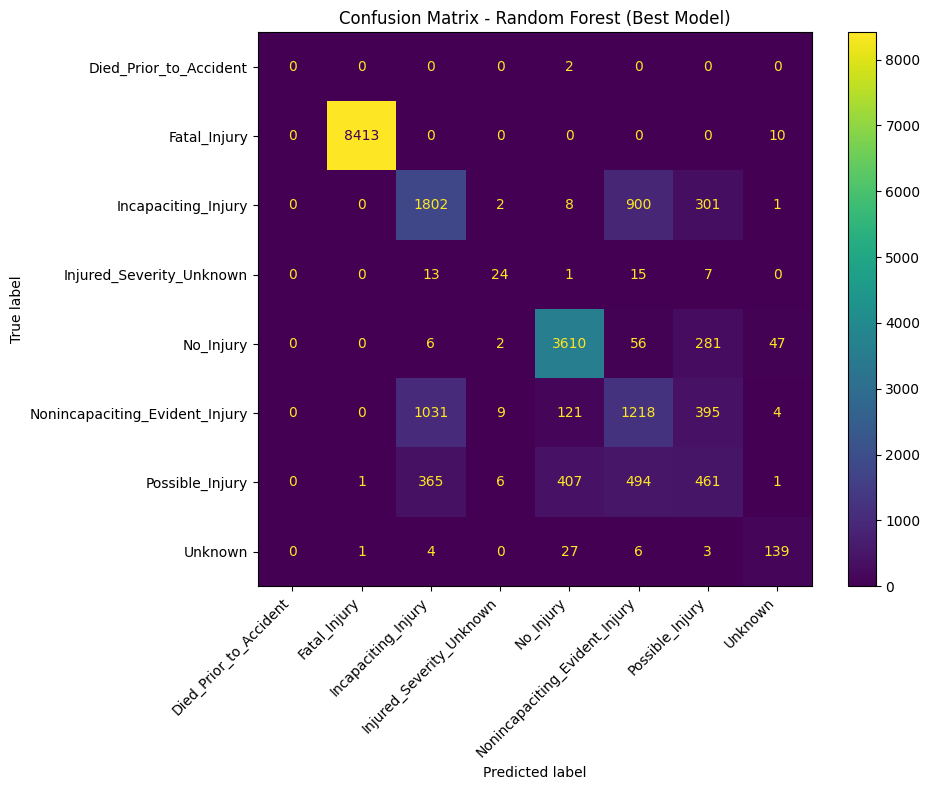

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))  # larger figure
disp = ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test, y_test, cmap="viridis", ax=ax
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.title("Confusion Matrix - Random Forest (Best Model)")
plt.tight_layout()
plt.show()

The confusion matrix shows:

- **Fatal_Injury** is classified extremely well due to its dominance in the dataset.

- **Minority classes** such as *Died_Prior_to_Accident* and *Injured_Severity_Unknown* are rarely detected — they are absorbed into Fatal or Non-evident categories.

- There is **notable confusion between Incapacitating, Non-evident, and Possible injury,** reflecting semantic overlap in injury definitions.

These results confirm that **class imbalance is the core challenge**, limiting recognition of rare injury outcomes.

The baseline DummyClassifier achieved significantly lower macro-F1 compared to all trained models, confirming that the learned models capture meaningful patterns beyond simple majority-class prediction.

All four models achieved similar accuracy (≈0.77–0.80), but accuracy is misleading because the dataset is highly imbalanced. Fatal_Injury alone represents 41.7% of cases, while some categories contain fewer than 1% of samples. Under these conditions, macro-F1 is a more reliable metric, as it reflects performance across minority classes.

Logistic Regression and Linear SVC produced the lowest macro-F1 scores (0.5059 and 0.5025). Their linear structure and reliance on one-hot encoded features make them less suited to complex, nonlinear categorical relationships, resulting in majority-class bias.

Tree-based models performed best. Random Forest achieved the highest macro-F1 (0.5486), while Gradient Boosting achieved the highest accuracy, while Random Forest achieved the best macro-F1 score, making it the most balanced model for this imbalanced classification task.

The confusion matrix shows near-perfect prediction for Fatal_Injury (e.g., 8,413 correct cases), but frequent misclassification of rare categories, indicating difficulty distinguishing fine-grained severity levels.


## **8. Discussion**

The evaluation results show that all trained models substantially outperform the baseline DummyClassifier, confirming that the selected features contain meaningful predictive signal for injury severity classification.

Although all four trained models achieved similar accuracy (around 0.78–0.80), accuracy alone is misleading because the dataset is highly imbalanced. The **Fatal_Injury** class accounts for 41.7% of cases, while some classes represent fewer than 1% of the data. Under these conditions, a model can achieve high accuracy by favouring majority classes. **Macro-F1 is therefore the more informative metric**, as it evaluates performance equally across all classes.

The linear models, **Logistic Regression** and **Linear SVC**, produced the lowest macro-F1 scores. This suggests that linear decision boundaries are less effective for modelling complex interactions between one-hot encoded categorical variables.

Among the tuned models, the tree-based approaches performed best. **Random Forest** achieved the highest macro-F1 score (0.5486), while **Gradient Boosting** achieved the highest accuracy (0.7974). This indicates that tree-based models are better able to capture nonlinear relationships and interactions between accident-related factors.

The confusion matrix provides further insight into model behaviour. **Fatal_Injury** is predicted extremely well, whereas rare classes such as **Died_Prior_to_Accident** and **Injured_Severity_Unknown** are rarely recognised correctly. In addition, there is noticeable confusion between **Incapacitating Injury**, **Nonincapacitating Evident Injury**, and **Possible Injury**, suggesting overlap between neighbouring severity levels.

Overall, the main challenge in this task is not fitting a model, but achieving balanced performance across minority injury classes under severe class imbalance.


## **9. Conclusion**

This project developed and compared multiple end-to-end machine learning pipelines for predicting injury severity from road accident data. The workflow included exploratory data analysis, preprocessing of mixed feature types, stratified train/test splitting, cross-validation, hyperparameter tuning, and evaluation on a held-out test set.

The results showed that all trained models outperformed the baseline classifier, confirming that accident-related features contain useful predictive information. However, the dataset’s strong class imbalance made overall accuracy insufficient as a standalone metric. Macro-F1 provided a more reliable view of model quality by reflecting performance across all injury classes.

Among the evaluated models, **Random Forest** achieved the best balance of performance, obtaining the highest macro-F1 score, while **Gradient Boosting** achieved the highest accuracy. This suggests that tree-based methods are better suited than linear models for this task because they can capture nonlinear relationships and interactions between categorical accident features.

Overall, the project demonstrates that injury severity can be predicted to a useful extent using tabular machine learning pipelines, but performance on rare injury categories remains limited. This highlights the importance of class-aware evaluation and careful model selection in imbalanced multi-class classification problems.


## **10. Limitations and Future Improvements**

This project has several limitations. First, the target variable is highly imbalanced, which makes it difficult for models to learn minority injury categories effectively. As a result, rare classes are often misclassified despite reasonable overall accuracy.

Second, most features in the dataset are categorical and encoded independently using one-hot encoding. While this is effective for many models, it may not capture deeper structure or similarity between related categories.

Third, the project focuses on predictive performance rather than causal interpretation. The identified patterns should therefore not be interpreted as direct causes of injury severity.

There are several directions for future improvement:

* apply resampling methods such as SMOTE or class-balanced sampling
* explore more advanced boosting methods such as XGBoost, LightGBM, or CatBoost
* use class-specific recall and precision analysis to better assess minority-class behaviour
* perform feature importance or SHAP-based interpretation for improved explainability
* investigate grouping or hierarchical treatment of very rare severity classes to reduce ambiguity

These improvements could help produce a more balanced and interpretable model for injury severity prediction.


## **11. Feature Importance Analysis**

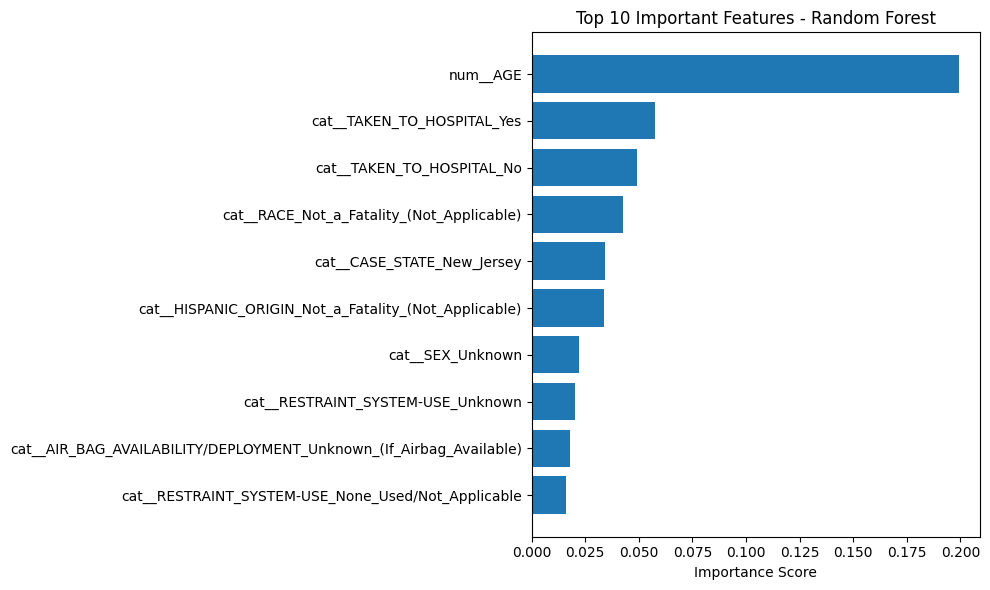

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract fitted preprocessor and classifier from pipeline
preprocessor = best_rf.named_steps["preprocess"]
rf_model = best_rf.named_steps["clf"]

# Get transformed feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importances from Random Forest
importances = rf_model.feature_importances_

# Create importance table
feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Top 10 most important features
top_features = feat_imp_df.sort_values(by="importance", ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features - Random Forest")
plt.tight_layout()
plt.show()

Feature importance was extracted from the best-performing Random Forest model to improve interpretability. The plot shows that **AGE** is the most influential predictor, followed by variables related to hospital transfer, restraint system use, and other accident-record attributes.

Although some encoded feature names are less intuitive due to one-hot encoding, the overall result shows that the model is not relying on a single variable alone. Instead, injury severity prediction is influenced by a combination of demographic, crash-response, and occupant-related factors.
